# Data Preprocessing Tools

## Importing the libraries & dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd 

In [2]:
df = pd.read_csv('Data.csv')
df 

,Country,Age,Salary,Purchased
0,France,44.0,72000.0,No
1,Spain,27.0,48000.0,Yes
2,Germany,30.0,54000.0,No
3,Spain,38.0,61000.0,No
4,Germany,40.0,NaN,Yes
5,France,35.0,58000.0,Yes
6,Spain,NaN,52000.0,No
7,France,48.0,79000.0,Yes
8,Germany,50.0,83000.0,No
9,France,37.0,67000.0,Yes


In [3]:
X = df.iloc[: , :-1] # all the independent in X except the the dependent 
y = df.iloc[:,-1] # the only dependent column

In [4]:
X 

,Country,Age,Salary
0,France,44.0,72000.0
1,Spain,27.0,48000.0
2,Germany,30.0,54000.0
3,Spain,38.0,61000.0
4,Germany,40.0,NaN
5,France,35.0,58000.0
6,Spain,NaN,52000.0
7,France,48.0,79000.0
8,Germany,50.0,83000.0
9,France,37.0,67000.0


In [5]:
y 

0     No
1    Yes
2     No
3     No
4    Yes
5    Yes
6     No
7    Yes
8     No
9    Yes
Name: Purchased, dtype: object

## Taking care of missing data

In [6]:
from sklearn.impute import SimpleImputer
imputer  = SimpleImputer(missing_values= np.nan , strategy= 'mean')
imputer.fit(X.iloc[: ,1:3]) # --> Expect age and salary cuz they're numeric numbers 
X.iloc[: ,1:3] = imputer.transform(X.iloc[:, 1:3]) # Update the Dataset 

## Encoding categorical data

### Encoding the Independent Variable

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder' , OneHotEncoder(), [0])] , remainder= 'passthrough')
X = np.array(ct.fit_transform(X))

In [8]:
X # Now the Countries Col is stored as numbers after re-encoded 

array([[1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 4.40000000e+01,
        7.20000000e+04],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 2.70000000e+01,
        4.80000000e+04],
       [0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 3.00000000e+01,
        5.40000000e+04],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 3.80000000e+01,
        6.10000000e+04],
       [0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 4.00000000e+01,
        6.37777778e+04],
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 3.50000000e+01,
        5.80000000e+04],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 3.87777778e+01,
        5.20000000e+04],
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 4.80000000e+01,
        7.90000000e+04],
       [0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 5.00000000e+01,
        8.30000000e+04],
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 3.70000000e+01,
        6.70000000e+04]])

### Encoding the Dependent Variable

In [9]:
from sklearn.preprocessing import LabelEncoder 
le = LabelEncoder()
y= le.fit_transform(y)

In [10]:
y

array([0, 1, 0, 0, 1, 1, 0, 1, 0, 1])

## Splitting the dataset into the Training set and Test set

In [11]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X,y, test_size= 0.2 , random_state= 1) 


In [12]:
X_test

array([[0.0e+00, 1.0e+00, 0.0e+00, 3.0e+01, 5.4e+04],
       [1.0e+00, 0.0e+00, 0.0e+00, 3.7e+01, 6.7e+04]])

In [13]:
X_train

array([[0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 3.87777778e+01,
        5.20000000e+04],
       [0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 4.00000000e+01,
        6.37777778e+04],
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 4.40000000e+01,
        7.20000000e+04],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 3.80000000e+01,
        6.10000000e+04],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 2.70000000e+01,
        4.80000000e+04],
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 4.80000000e+01,
        7.90000000e+04],
       [0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 5.00000000e+01,
        8.30000000e+04],
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 3.50000000e+01,
        5.80000000e+04]])

In [14]:
y_train

array([0, 1, 0, 0, 1, 1, 0, 1])

In [15]:
y_test

array([0, 1])

## Feature Scaling

In [16]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train[: , 3:] = sc.fit_transform(X_train[: ,3:])
X_test[: , 3:] = sc.transform(X_test[: , 3:])

In [17]:
X_train

array([[ 0.        ,  0.        ,  1.        , -0.19159184, -1.07812594],
       [ 0.        ,  1.        ,  0.        , -0.01411729, -0.07013168],
       [ 1.        ,  0.        ,  0.        ,  0.56670851,  0.63356243],
       [ 0.        ,  0.        ,  1.        , -0.30453019, -0.30786617],
       [ 0.        ,  0.        ,  1.        , -1.90180114, -1.42046362],
       [ 1.        ,  0.        ,  0.        ,  1.14753431,  1.23265336],
       [ 0.        ,  1.        ,  0.        ,  1.43794721,  1.57499104],
       [ 1.        ,  0.        ,  0.        , -0.74014954, -0.56461943]])

In [18]:
X_test

array([[ 0.        ,  1.        ,  0.        , -1.46618179, -0.9069571 ],
       [ 1.        ,  0.        ,  0.        , -0.44973664,  0.20564034]])

In [19]:
y_train

array([0, 1, 0, 0, 1, 1, 0, 1])

In [20]:
y_test

array([0, 1])

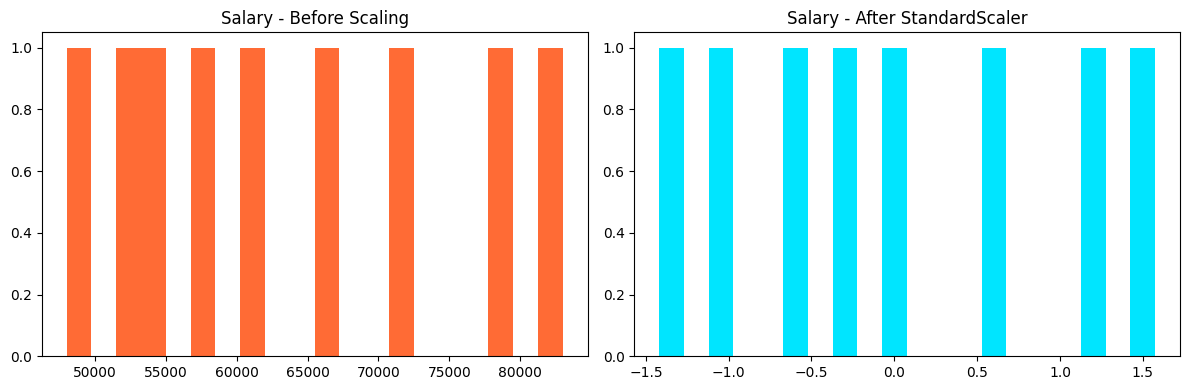

Mean after scaling: 0.0000
Std after scaling: 1.0000


In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before scaling
axes[0].hist(df['Salary'], bins=20, color='#ff6b35')
axes[0].set_title('Salary - Before Scaling')

# After scaling
axes[1].hist(X_train[:, 4], bins=20, color='#00e5ff')
axes[1].set_title('Salary - After StandardScaler')

plt.tight_layout()
plt.show()

# Confirm: mean should be ~0 and std ~1
print(f"Mean after scaling: {X_train[:, 4].mean():.4f}")  # ≈ 0
print(f"Std after scaling: {X_train[:, 4].std():.4f}")    # ≈ 1